#LeNet-5 MNIST Lab

This Jupyter-style notebook contains:

1. Boilerplate PyTorch code for the **original LeNet-style** network (tanh + AvgPool) with **GPU support**.
2. Train / validation / test split, logging, and plotting of loss & accuracy curves.
3. Utility cells to toggle experiments (MaxPool, ReLU, L1, Dropout) quickly.
4. The **10-mark assignment** with clearly numbered questions and deliverables.

---

In [1]:
# ----------------------------
# Config / Hyperparameters
# ----------------------------
import os
import time
import math
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Edit these values before running
CFG = {
    "batch_size": 128,
    "test_batch_size": 1000,
    "epochs": 5,
    "lr": 0.01,
    "momentum": 0.9,
    "seed": 1,
    "log_interval": 100,
    "val_size": 10000,
    "save_dir": "outputs_notebook",
    # Experiment toggles (change to True/False)
    "use_maxpool": False,   # if True, replaces AvgPool with MaxPool
    "use_relu": False,      # if True, replaces Tanh with ReLU
    "l1_lambda": 0.0,       # set >0 to add L1 penalty
    "use_dropout": False,   # if True, adds Dropout between FC layers
}

os.makedirs(CFG["save_dir"], exist_ok=True)

# reproducibility
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Data preparation

In [2]:
transform = transforms.Compose([
    transforms.Pad(2),  # 28x28 -> 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

val_size = CFG["val_size"]
train_size = len(full_train) - val_size
if train_size <= 0:
    raise ValueError("val-size too large; must leave >0 training examples")

train_dataset, val_dataset = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(CFG["seed"]))

train_loader = DataLoader(train_dataset, batch_size=CFG["batch_size"], shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CFG["test_batch_size"], shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CFG["test_batch_size"], shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:59<00:00, 167kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 105kB/s]
100%|██████████| 1.65M/1.65M [00:23<00:00, 68.9kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.56MB/s]

Train: 50000, Val: 10000, Test: 10000


Model: LeNet-style (configurable)

In [3]:
class LeNetConfigurable(nn.Module):
    def __init__(self, num_classes=10, use_maxpool=False, use_relu=False, use_dropout=False):
        super(LeNetConfigurable, self).__init__()
        act = nn.ReLU if use_relu else nn.Tanh
        pool = nn.MaxPool2d if use_maxpool else nn.AvgPool2d
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.act1 = act()
        self.pool1 = pool(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.act2 = act()
        self.pool2 = pool(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)
        self.act3 = act()

        self.fc1 = nn.Linear(120, 84)
        self.act4 = act()
        self.use_dropout = use_dropout
        if use_dropout:
            self.drop = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.act3(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.act4(x)
        if self.use_dropout:
            x = self.drop(x)
        x = self.fc2(x)
        return x

Train / Evaluate utilities (with optional L1)

In [4]:
criterion = nn.CrossEntropyLoss()

def l1_penalty(model):
    l1 = 0.0
    for p in model.parameters():
        l1 = l1 + p.abs().sum()
    return l1


def train_one_epoch(model, device, loader, optimizer, epoch, cfg):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    start = time.time()
    for batch_idx, (data, target) in enumerate(loader, 1):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        if cfg["l1_lambda"] > 0:
            loss = loss + cfg["l1_lambda"] * l1_penalty(model)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)
        preds = outputs.argmax(dim=1)
        correct += preds.eq(target).sum().item()
        total += data.size(0)

        if batch_idx % cfg["log_interval"] == 0:
            avg = running_loss / total
            acc = 100.0 * correct / total
            print(f"Epoch {epoch} Batch {batch_idx}/{len(loader)}  AvgLoss: {avg:.4f}  Acc: {acc:.2f}%")
    elapsed = time.time() - start
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    print(f"Epoch {epoch} training finished in {elapsed:.2f}s  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.2f}%")
    return epoch_loss, epoch_acc


def evaluate(model, device, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)
            running_loss += loss.item() * data.size(0)
            preds = outputs.argmax(dim=1)
            correct += preds.eq(target).sum().item()
            total += data.size(0)
    avg_loss = running_loss / total
    acc = 100.0 * correct / total
    return avg_loss, acc

Main training routine (runs with current CFG)

In [12]:
def run_experiment(cfg, verbose=True, file_name="lenet_best.pth"):
    model = LeNetConfigurable(use_maxpool=cfg["use_maxpool"], use_relu=cfg["use_relu"], use_dropout=cfg["use_dropout"]).to(device)
    optimizer = optim.SGD(model.parameters(), lr=cfg["lr"], momentum=cfg["momentum"])

    best_val_acc = 0.0
    history = []
    for epoch in range(1, cfg["epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, device, train_loader, optimizer, epoch, cfg)
        val_loss, val_acc = evaluate(model, device, val_loader)
        if verbose:
            print(f"Epoch {epoch}  VAL Loss: {val_loss:.4f}  VAL Acc: {val_acc:.2f}%")
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })
        # save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), os.path.join(cfg["save_dir"], file_name))
    # final test
    best_model = LeNetConfigurable(use_maxpool=cfg["use_maxpool"], use_relu=cfg["use_relu"], use_dropout=cfg["use_dropout"]).to(device)
    best_model.load_state_dict(torch.load(os.path.join(cfg["save_dir"], file_name), map_location=device))
    test_loss, test_acc = evaluate(best_model, device, test_loader)
    print(f"Test Loss: {test_loss:.4f}  Test Acc: {test_acc:.2f}%")
    return history, test_loss, test_acc

Run baseline experiment (tanh + AvgPool, no L1, no dropout) using CFG values

In [7]:
# Make a copy of CFG to ensure baseline settings
baseline_cfg = CFG.copy()
baseline_cfg.update({"use_maxpool": False, "use_relu": False, "l1_lambda": 0.0, "use_dropout": False})

history_baseline, test_loss_baseline, test_acc_baseline = run_experiment(baseline_cfg)

# Save history to CSV
hist_df = pd.DataFrame(history_baseline)
hist_df.to_csv(os.path.join(CFG["save_dir"], "baseline_history.csv"), index=False)
print("Baseline history saved.")

Epoch 1 Batch 100/391  AvgLoss: 1.5905  Acc: 55.18%
Epoch 1 Batch 200/391  AvgLoss: 1.0476  Acc: 70.50%
Epoch 1 Batch 300/391  AvgLoss: 0.8118  Acc: 77.05%
Epoch 1 training finished in 11.47s  Loss: 0.6863  Acc: 80.56%
Epoch 1  VAL Loss: 0.2537  VAL Acc: 92.47%
Epoch 2 Batch 100/391  AvgLoss: 0.2301  Acc: 93.22%
Epoch 2 Batch 200/391  AvgLoss: 0.2142  Acc: 93.75%
Epoch 2 Batch 300/391  AvgLoss: 0.2000  Acc: 94.07%
Epoch 2 training finished in 10.62s  Loss: 0.1897  Acc: 94.42%
Epoch 2  VAL Loss: 0.1352  VAL Acc: 95.97%
Epoch 3 Batch 100/391  AvgLoss: 0.1283  Acc: 96.40%
Epoch 3 Batch 200/391  AvgLoss: 0.1256  Acc: 96.49%
Epoch 3 Batch 300/391  AvgLoss: 0.1168  Acc: 96.69%
Epoch 3 training finished in 10.54s  Loss: 0.1129  Acc: 96.79%
Epoch 3  VAL Loss: 0.0978  VAL Acc: 97.16%
Epoch 4 Batch 100/391  AvgLoss: 0.0915  Acc: 97.52%
Epoch 4 Batch 200/391  AvgLoss: 0.0850  Acc: 97.69%
Epoch 4 Batch 300/391  AvgLoss: 0.0826  Acc: 97.69%
Epoch 4 training finished in 10.73s  Loss: 0.0823  Acc: 97

Plotting utilities

Saved outputs_notebook\baseline_loss.png
Saved outputs_notebook\baseline_acc.png


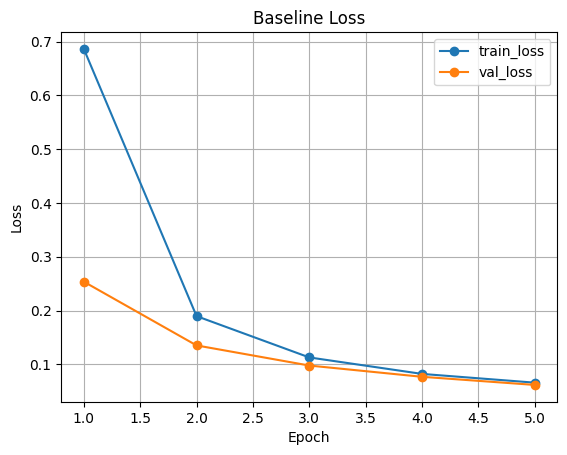

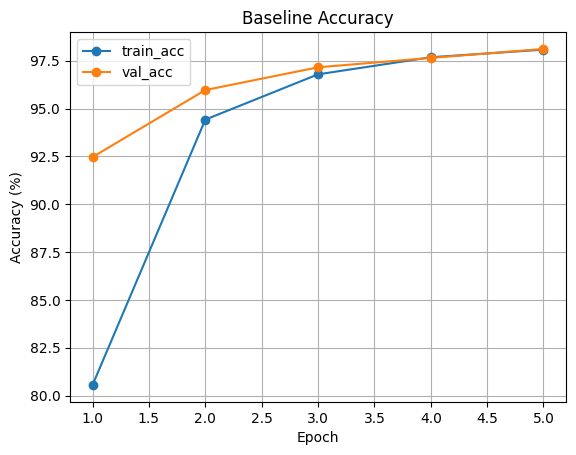

In [8]:
def plot_history(history, title_prefix, save_dir):
    df = pd.DataFrame(history)
    epochs = df['epoch']
    plt.figure(); plt.plot(epochs, df['train_loss'], marker='o', label='train_loss'); plt.plot(epochs, df['val_loss'], marker='o', label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'{title_prefix} Loss'); plt.legend(); plt.grid(True)
    loss_path = os.path.join(save_dir, f"{title_prefix.replace(' ','_').lower()}_loss.png")
    plt.savefig(loss_path); print(f"Saved {loss_path}")

    plt.figure(); plt.plot(epochs, df['train_acc'], marker='o', label='train_acc'); plt.plot(epochs, df['val_acc'], marker='o', label='val_acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title(f'{title_prefix} Accuracy'); plt.legend(); plt.grid(True)
    acc_path = os.path.join(save_dir, f"{title_prefix.replace(' ','_').lower()}_acc.png")
    plt.savefig(acc_path); print(f"Saved {acc_path}")

# plot baseline
plot_history(history_baseline, 'Baseline', CFG['save_dir'])

#**Assignment (10 marks)**

**Instructions:**
- Use the notebook to run experiments. Keep hyperparameters (epochs, lr, batch size, seed) identical across experiments for fair comparison.
- For each task: save code, training log (CSV), final test accuracy, and provide a short analysis (3-4 sentences).

**Tasks (total 10 marks)**

------------------------------------------------------------------------------------------------

**1. Baseline run — 0 marks[Must be DONE!!]**

- Run the baseline provided above (tanh + AvgPool, no regularizers).
- Submit: `lenet_best.pth`, `baseline_history.csv`, final test accuracy, and a short paragraph (3–4 sentences) interpreting the training behavior.

**Marking (0 marks):[Must be DONE!!]**
- 1 mark: Baseline artifacts included.
- 1 mark: Reasonable interpretation.

### Answer 1

- Ran the baseline as provided.
- Artifacts are as follows:
    - `outputs_notebook/baseline_history.csv`
    - `lenet_best.pth`
- Observations and interpretation:
    - Dropping epochs to 5 did not impact performance in any aspect while reducing training time.
    - Smooth training convergence with consistent drop in validation.
    - Absence of any symptom of overfitting such as val loss plateau or the like.

------------------------------------------------------------------------------------------------

**2. Replace AveragePool with MaxPool — 2 marks**

- Change pooling to MaxPool (set `CFG['use_maxpool']=True`) and re-run with the same hyperparameters.
- Submit modified notebook cell (or a separate `.py`), training log CSV, final test accuracy, and a short comparison (3–4 sentences) vs. baseline.

**Marking (2 marks):**
- 1 mark: Code and results included.
- 1 mark: Insightful comparison.

Epoch 1 Batch 100/391  AvgLoss: 1.6143  Acc: 54.09%
Epoch 1 Batch 200/391  AvgLoss: 1.0438  Acc: 70.41%
Epoch 1 Batch 300/391  AvgLoss: 0.7908  Acc: 77.60%
Epoch 1 training finished in 11.37s  Loss: 0.6550  Acc: 81.39%
Epoch 1  VAL Loss: 0.1717  VAL Acc: 95.13%
Epoch 2 Batch 100/391  AvgLoss: 0.1602  Acc: 95.28%
Epoch 2 Batch 200/391  AvgLoss: 0.1476  Acc: 95.76%
Epoch 2 Batch 300/391  AvgLoss: 0.1364  Acc: 96.06%
Epoch 2 training finished in 11.75s  Loss: 0.1273  Acc: 96.31%
Epoch 2  VAL Loss: 0.0938  VAL Acc: 97.25%
Epoch 3 Batch 100/391  AvgLoss: 0.0896  Acc: 97.45%
Epoch 3 Batch 200/391  AvgLoss: 0.0860  Acc: 97.52%
Epoch 3 Batch 300/391  AvgLoss: 0.0844  Acc: 97.60%
Epoch 3 training finished in 11.48s  Loss: 0.0828  Acc: 97.64%
Epoch 3  VAL Loss: 0.0730  VAL Acc: 97.76%
Epoch 4 Batch 100/391  AvgLoss: 0.0770  Acc: 97.84%
Epoch 4 Batch 200/391  AvgLoss: 0.0705  Acc: 98.01%
Epoch 4 Batch 300/391  AvgLoss: 0.0676  Acc: 98.07%
Epoch 4 training finished in 11.02s  Loss: 0.0657  Acc: 98

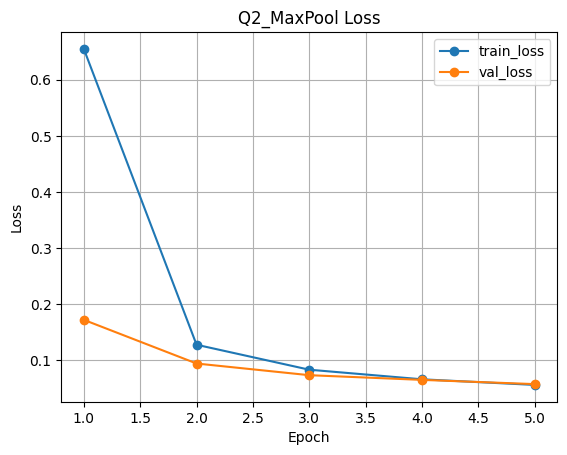

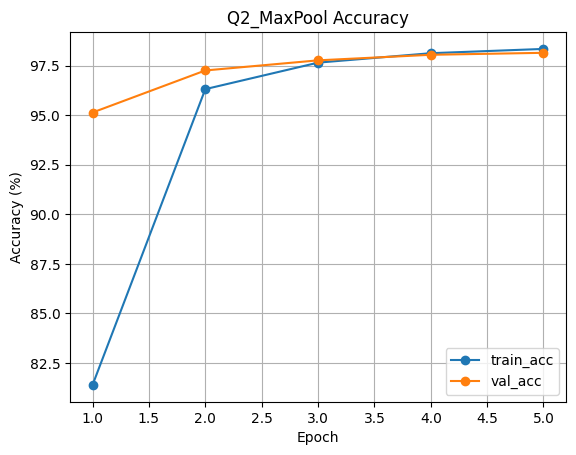

In [16]:
CFG.update({"use_maxpool": True})
history_max, test_loss, test_acc= run_experiment(CFG, file_name="Q2_Max_Pool.pth")
hist_df= pd.DataFrame(history_max)
hist_df.to_csv(os.path.join(CFG["save_dir"], "Q2_Max_Pool.csv"), index=False)
plot_history(history_max, title_prefix="Q2_MaxPool", save_dir=CFG['save_dir'])

### Answer 2

- Ran the baseline as provided.
- Artifacts are as follows:
    - `outputs_notebook/Q2_Max_Pool.csv`
    - `Q2_Max_Pool.pth`

- Observations, Comparison and interpretation:
    - Dropping epochs to 5 did not impact performance in any aspect while reducing training time, similiar to baseline provision.
    - Smooth training convergence with consistent drop in validation.
    - Absence of any symptom of overfitting such as val loss plateau or the like.
    - While the loss curve is similiar to in Q1, noticeably in Q2 final train_acc is greater than final val_acc unlike in Q1.
    
    - With average pool: Test Loss: 0.0542  Test Acc: 98.31%.
    - with Max pool: Test Loss: 0.0458  Test Acc: 98.59%.
        - Thus max pool performs slightly better in repeated attempts.
        - This is probably due to how max pool is better for translation invariance, necessary for MNIST
    

------------------------------------------------------------------------------------------------

**3. Replace tanh with ReLU — 2 marks**

- Change activations to ReLU (set `CFG['use_relu']=True`) and re-run.
- Submit results and brief analysis (3–4 sentences) comparing training speed, stability, and accuracy.

**Marking (2 marks):**
- 1 mark: Code & results included.
- 1 mark: Clear explanation.

Epoch 1 Batch 100/391  AvgLoss: 1.9455  Acc: 38.98%
Epoch 1 Batch 200/391  AvgLoss: 1.2128  Acc: 62.11%
Epoch 1 Batch 300/391  AvgLoss: 0.9054  Acc: 71.79%
Epoch 1 training finished in 11.14s  Loss: 0.7487  Acc: 76.73%
Epoch 1  VAL Loss: 0.2231  VAL Acc: 93.01%
Epoch 2 Batch 100/391  AvgLoss: 0.1792  Acc: 94.39%
Epoch 2 Batch 200/391  AvgLoss: 0.1655  Acc: 94.87%
Epoch 2 Batch 300/391  AvgLoss: 0.1527  Acc: 95.27%
Epoch 2 training finished in 10.96s  Loss: 0.1454  Acc: 95.56%
Epoch 2  VAL Loss: 0.1150  VAL Acc: 96.39%
Epoch 3 Batch 100/391  AvgLoss: 0.0922  Acc: 97.06%
Epoch 3 Batch 200/391  AvgLoss: 0.0936  Acc: 97.18%
Epoch 3 Batch 300/391  AvgLoss: 0.0904  Acc: 97.26%
Epoch 3 training finished in 11.10s  Loss: 0.0901  Acc: 97.31%
Epoch 3  VAL Loss: 0.0908  VAL Acc: 97.30%
Epoch 4 Batch 100/391  AvgLoss: 0.0746  Acc: 97.56%
Epoch 4 Batch 200/391  AvgLoss: 0.0752  Acc: 97.62%
Epoch 4 Batch 300/391  AvgLoss: 0.0733  Acc: 97.74%
Epoch 4 training finished in 11.30s  Loss: 0.0715  Acc: 97

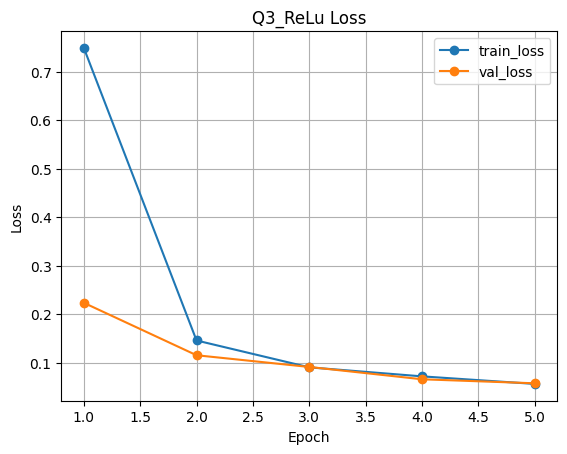

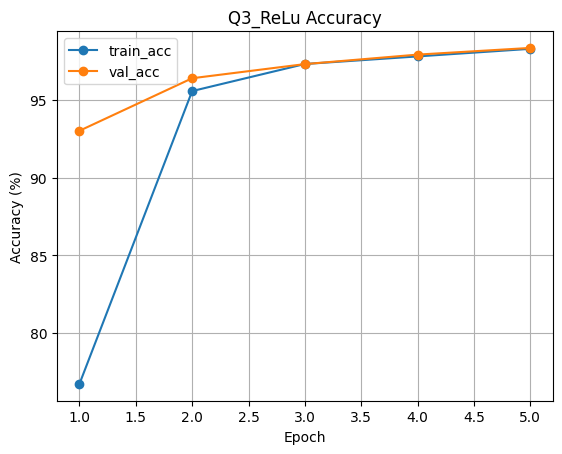

In [17]:
CFG.update({
    "use_maxpool": False,
    "use_relu": True,
})
history_relu, test_loss, test_acc = run_experiment(CFG, file_name="Q3_ReLu.pth")
hist_df_relu=pd.DataFrame(history_relu)
hist_df_relu.to_csv(os.path.join(CFG["save_dir"], "Q3_ReLu.csv"), index=False)
plot_history(history_relu, title_prefix="Q3_ReLu", save_dir=CFG['save_dir'])

### Answer 3
- Noticeably ReLu converged faster than the baseline variants, converging at the 3rd epoch compared to the baseline's at 4th epoch.

- Performance-wise, there are no distinctions to be made, as compared to baseline in Q1, there is a slight performance boost.
    - Q1-Baseline: Test Loss: 0.0542  Test Acc: 98.31%
    - Q2-With Relu: Test Loss: 0.0502  Test Acc: 98.46%

- Artifacts are located as:
    - `outputs_notebook/Q3_ReLu.csv`
    -  `outputs_notebook/Q3_ReLu.pth`

------------------------------------------------------------------------------------------------

**4. Add L1 regularization — 2 marks**

- Add L1 regularization by setting `CFG['l1_lambda']` to a small value (try `1e-6`, `1e-5`). Implemented in training loop already.
- Re-run baseline architecture but with L1. Submit code, lambda value, training logs, final accuracy, and a short discussion (3–4 sentences).

**Marking (2 marks):**
- 1 mark: Correct L1 implementation + results.
- 1 mark: Reasoned analysis.

Epoch 1 Batch 100/391  AvgLoss: 1.6479  Acc: 58.23%
Epoch 1 Batch 200/391  AvgLoss: 1.0894  Acc: 72.12%
Epoch 1 Batch 300/391  AvgLoss: 0.8448  Acc: 78.26%
Epoch 1 training finished in 11.72s  Loss: 0.7142  Acc: 81.60%
Epoch 1  VAL Loss: 0.2435  VAL Acc: 92.88%
Epoch 2 Batch 100/391  AvgLoss: 0.2507  Acc: 93.55%
Epoch 2 Batch 200/391  AvgLoss: 0.2350  Acc: 93.78%
Epoch 2 Batch 300/391  AvgLoss: 0.2211  Acc: 94.18%
Epoch 2 training finished in 11.43s  Loss: 0.2076  Acc: 94.52%
Epoch 2  VAL Loss: 0.1413  VAL Acc: 95.73%
Epoch 3 Batch 100/391  AvgLoss: 0.1535  Acc: 96.25%
Epoch 3 Batch 200/391  AvgLoss: 0.1485  Acc: 96.35%
Epoch 3 Batch 300/391  AvgLoss: 0.1424  Acc: 96.50%
Epoch 3 training finished in 11.42s  Loss: 0.1379  Acc: 96.58%
Epoch 3  VAL Loss: 0.0981  VAL Acc: 96.96%
Epoch 4 Batch 100/391  AvgLoss: 0.1169  Acc: 97.16%
Epoch 4 Batch 200/391  AvgLoss: 0.1145  Acc: 97.30%
Epoch 4 Batch 300/391  AvgLoss: 0.1117  Acc: 97.39%
Epoch 4 training finished in 11.47s  Loss: 0.1077  Acc: 97

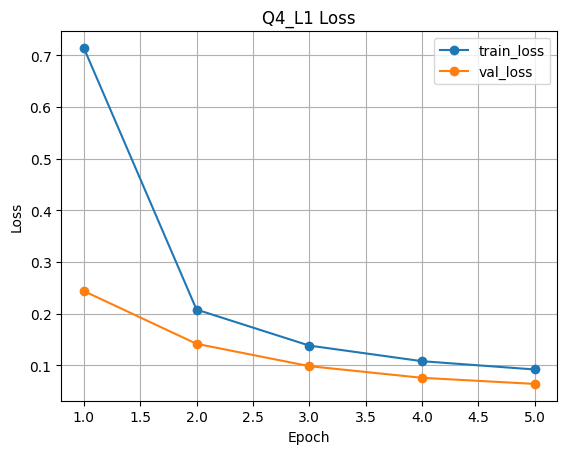

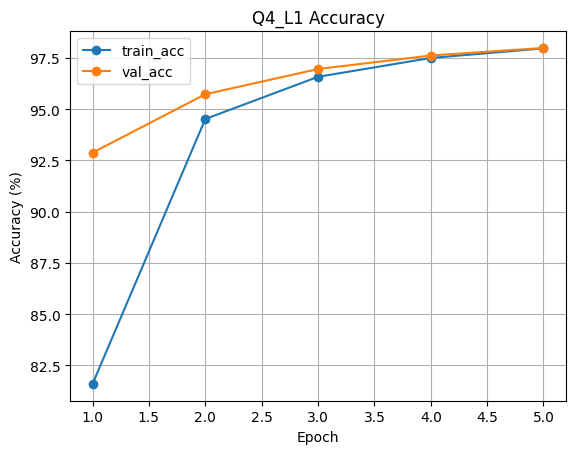

In [18]:
CFG.update({
    "use_relu": False,
    "l1_lambda": 1e-5,
})
history_l1, test_loss, test_acc = run_experiment(CFG, file_name="Q4_L1.pth")
hist_df_l1=pd.DataFrame(history_l1)
hist_df_l1.to_csv(os.path.join(CFG["save_dir"], "Q4_L1.csv"), index=False)
plot_history(history_l1, title_prefix="Q4_L1", save_dir=CFG['save_dir'])

### Answer 4
- Key observation is that validation loss is consistently lower than training loss.
    - This is not a sign of overfitting.
    - Training loss has an additional L1 penalty that the validation loss doesn't have.

- Training converged quickly, and no signs of overfitting

- Test Loss: 0.0572  Test Acc: 98.14%

- Artifacts are located as:
    - `outputs_notebook/Q4_L1.csv`
    -  `outputs_notebook/Q4_L1.pth`

------------------------------------------------------------------------------------------------

**5. Add Dropout and compare — 2 Marks**

- Set `CFG['use_dropout']=True` to add `nn.Dropout(p=0.5)` between FC layers and re-run. Submit notes and comparison.
- This is bonus and does not count toward the 10 marks, but is encouraged.

**Marking (2 marks):**
- 1 mark: Correct Dropout implementation + results.
- 1 mark: Reasoned analysis.

Epoch 1 Batch 100/391  AvgLoss: 1.5796  Acc: 53.09%
Epoch 1 Batch 200/391  AvgLoss: 1.0640  Acc: 69.24%
Epoch 1 Batch 300/391  AvgLoss: 0.8413  Acc: 76.00%
Epoch 1 training finished in 10.74s  Loss: 0.7242  Acc: 79.48%
Epoch 1  VAL Loss: 0.2352  VAL Acc: 93.06%
Epoch 2 Batch 100/391  AvgLoss: 0.2770  Acc: 92.73%
Epoch 2 Batch 200/391  AvgLoss: 0.2664  Acc: 93.05%
Epoch 2 Batch 300/391  AvgLoss: 0.2492  Acc: 93.49%
Epoch 2 training finished in 15.20s  Loss: 0.2359  Acc: 93.84%
Epoch 2  VAL Loss: 0.1335  VAL Acc: 95.90%
Epoch 3 Batch 100/391  AvgLoss: 0.1673  Acc: 95.79%
Epoch 3 Batch 200/391  AvgLoss: 0.1680  Acc: 95.86%
Epoch 3 Batch 300/391  AvgLoss: 0.1619  Acc: 96.00%
Epoch 3 training finished in 14.48s  Loss: 0.1562  Acc: 96.17%
Epoch 3  VAL Loss: 0.0944  VAL Acc: 97.11%
Epoch 4 Batch 100/391  AvgLoss: 0.1297  Acc: 96.90%
Epoch 4 Batch 200/391  AvgLoss: 0.1290  Acc: 96.94%
Epoch 4 Batch 300/391  AvgLoss: 0.1265  Acc: 97.03%
Epoch 4 training finished in 12.03s  Loss: 0.1245  Acc: 97

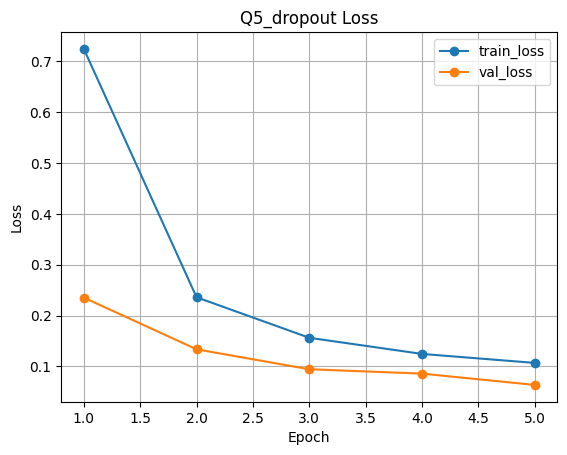

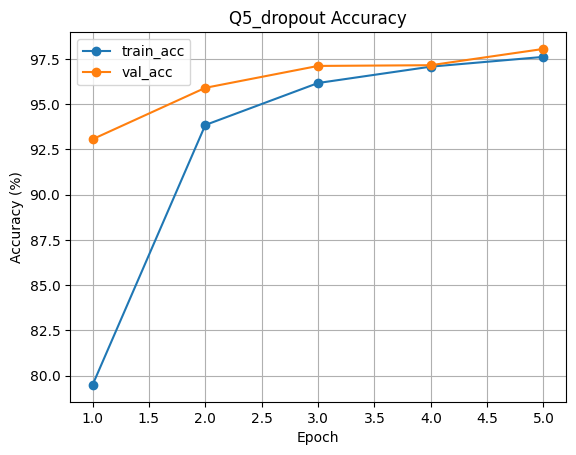

In [19]:
CFG.update({
    "use_dropout": True
})
history_dropout, test_loss, test_acc = run_experiment(CFG, file_name="Q5_dropout.pth")
hist_df_dropout=pd.DataFrame(history_dropout)
hist_df_dropout.to_csv(os.path.join(CFG["save_dir"], "Q5_dropout.csv"), index=False)
plot_history(history_dropout, title_prefix="Q5_dropout", save_dir=CFG['save_dir'])

### Answer 5
- Noticeably slower initial training, but stable model convergence and no sign of overfitting.

- Compared to baseline, dropout hasn't affected training much with very similiar train/test performance, with a small reduction in training accuracy as expected by regularization affect.

- Artifacts are located as:
    - `outputs_notebook/Q5_dropout.csv`
    -  `outputs_notebook/Q5_dropout.pth`

------------------------------------------------------------------------------------------------

**Deliverables checklist**
1. Notebook with all experiments (or separate `.py` files) — code should be runnable.
2. Saved model files for each experiment (`.pth`).
3. Training logs (`.csv`) and a short PDF/Markdown report including:
   - Plots: train/val loss vs epoch, train/val accuracy vs epoch for each experiment.
   - A table summarizing final test accuracy for each variant.
   - Short answers for Tasks 1–4.